# Landing Page A/B Test — Conversion and Revenue Validation

*Statistical validation of a homepage A/B experiment · TripleTen Data Analysis program, Sprint 9 project*

An A/B experiment was run on the homepage of an e-commerce platform, comparing version **A (control)** against version **B (variant)**, with the goal of improving conversion rate and economic value per user.

**Decision to make:** which version should be implemented?

The analysis has to rest on statistical evidence rather than on raw differences, and has to account for behavior by traffic channel and user type.

> Each row is one user, exposed to exactly one version. `gasto` is greater than zero only when `converted` = 1, so spend comparisons must be filtered to converted users.

**Scope note.** Every test reported below was run on this dataset. Tests that would strengthen the analysis but were not performed — experiment-validation checks, distribution-free alternatives, interaction tests, resampling — are listed explicitly in *Section 7: Recommended Further Analysis* rather than implied anywhere in the results.

## Setup

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.stats import levene, ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

ALPHA = 0.05          # significance level used throughout
ASSETS = "assets"     # figures are exported here for the README and the infographic
os.makedirs(ASSETS, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "font.size": 11})

PALETTE = {"A": "#64748B", "B": "#2563EB"}   # A = control (grey), B = variant (blue)

%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv("landing_experiment.csv")
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

40,000 rows x 9 columns


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


## Section 1 — Load and validate the data

Structure, data types, completeness, and the consistency of every categorical variable before any comparison is made.

In [3]:
def run_initial_checks(df):
    """Print an initial data-quality and A/B test summary."""

    # 1. Dataset size and structure
    print("Dataset shape (rows, columns):", df.shape)
    print("\nData types:")
    print(df.dtypes)

    # 2. Missing values
    print("\nMissing values by column:")
    print(df.isna().sum())

    # 3. Duplicate rows
    print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

    # 4. Repeated user IDs
    print(f"\nRepeated user_id rows: {df['user_id'].duplicated().sum()}")

    # 5. Unique values in categorical columns
    categorical_columns = df.select_dtypes(include=["object", "category"]).columns
    print("\nUnique values in categorical columns:")
    for column in categorical_columns:
        print(f"{column}: {df[column].unique()}")

    # 6. Unique values in the conversion column
    print(f"\nUnique values in 'converted' column: {df['converted'].unique()}")


run_initial_checks(df)

Dataset shape (rows, columns): (40000, 9)

Data types:
user_id               str
date                  str
landing               str
region                str
dispositivo           str
traffic_source        str
user_type             str
converted           int64
gasto             float64
dtype: object

Missing values by column:
user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

Number of duplicate rows: 0

Repeated user_id rows: 0

Unique values in categorical columns:
user_id: <StringArray>
['26f3052e-8500-44ea-8fff-06de65258abb',
 '92378c09-4bbf-40c7-945e-82b84f392d22',
 'a4397360-40e5-45d6-a7ff-dcb4da2c9a1f',
 '7ca3a26f-1e6c-44aa-9b09-b8cb01112956',
 '8dc9593b-5b9c-479d-848b-a99493920419',
 '1b72e41d-e797-40b6-afb8-c2d79bee7552',
 '71897b47-3f4c-40ee-9e26-f458674755a3',
 'c00efddd-5cbb-4b7d-a1f3-1fa76866cff0',
 'f9ee7358-321d-448e-8788-90f64d

/tmp/ipykernel_224/4104541449.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns


✍️ **Comments:** 40,000 rows and 9 columns. No missing values, no fully duplicated rows, and no repeated user IDs — so each row is an independent observation of one user. The categorical values are consistent: `landing` contains only A and B, `dispositivo` only Mobile and Desktop, and the remaining category columns hold a small set of readable values.

📅 One item to address: `date` is stored as a string and is converted to datetime before any date-based reading. Column names and category labels are also translated to English so every table and chart reads in one language.

In [4]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Translate column names to English
df = df.rename(columns={"dispositivo": "device", "gasto": "spending"})

# Translate category labels to English
df["user_type"] = df["user_type"].replace({"Nuevo": "New", "Recurrente": "Returning"})

df.head()

,user_id,date,landing,region,device,traffic_source,user_type,converted,spending
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Returning,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,New,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,New,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,New,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,New,0,0.00


**Dataset description**

- `user_id` — Unique user identifier
- `date` — Date when the user was shown the page
- `landing` — Version of the page shown to the user
- `region` — User's geographic region
- `device` — Type of device used by the user
- `traffic_source` — Channel through which the user arrived
- `user_type` — User type based on prior history
- `converted` — Indicates whether the user converted
- `spending` — Amount spent by the user (0 if they did not convert)

### 1.1 Exploratory review of the key variables

In [5]:
# user_id: confirm one row per user
print(f"Number of unique user IDs: {df['user_id'].nunique():,}")
print(f"Total number of rows in the dataset: {len(df):,}")

# date: the window the experiment covers
print("\nMinimum date:", df["date"].min().date())
print("Maximum date:", df["date"].max().date())
print("Days covered:", df["date"].nunique())

# spending: overall and among converted users
print("\nSpending, all users:")
print(df["spending"].describe().round(2).to_string())
print("\nSpending, converted users only:")
print(df.loc[df["converted"] == 1, "spending"].describe().round(2).to_string())

Number of unique user IDs: 40,000
Total number of rows in the dataset: 40,000

Minimum date: 2026-01-01
Maximum date: 2026-01-28
Days covered: 28

Spending, all users:
count    40000.00
mean         9.33
std         25.67
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        303.68

Spending, converted users only:
count    5706.00
mean       65.37
std        30.90
min        12.12
25%        42.95
50%        59.86
75%        80.37
max       303.68


In [6]:
# Composition of each group: the experiment is only readable if the two arms
# are built from comparable users.
categorical_columns = ["device", "region", "user_type", "traffic_source"]

for column in categorical_columns:
    print(f"\n{column} by landing page (counts):")
    print(pd.crosstab(df["landing"], df[column], margins=True, dropna=False))

    print(f"\n{column} by landing page (row proportions):")
    print(pd.crosstab(df["landing"], df[column], normalize="index", dropna=False).round(3))


device by landing page (counts):
device   Desktop  Mobile    All
landing                        
A           7571   12411  19982
B           7600   12418  20018
All        15171   24829  40000

device by landing page (row proportions):
device   Desktop  Mobile
landing                 
A          0.379   0.621
B          0.380   0.620

region by landing page (counts):


region   Centro  Norte  Occidente  Oriente   Sur    All
landing                                                
A          4822   5553       3236     2309  4062  19982
B          4791   5613       3162     2475  3977  20018
All        9613  11166       6398     4784  8039  40000

region by landing page (row proportions):
region   Centro  Norte  Occidente  Oriente    Sur
landing                                          
A         0.241  0.278      0.162    0.116  0.203
B         0.239  0.280      0.158    0.124  0.199

user_type by landing page (counts):


user_type    New  Returning    All
landing                           
A          12992       6990  19982
B          13041       6977  20018
All        26033      13967  40000

user_type by landing page (row proportions):
user_type    New  Returning
landing                    
A          0.650      0.350
B          0.651      0.349

traffic_source by landing page (counts):
traffic_source    Ads  Email  Organic  Referral    All
landing                                               
A                5981   3087     8992      1922  19982
B                5954   3036     8995      2033  20018
All             11935   6123    17987      3955  40000

traffic_source by landing page (row proportions):
traffic_source    Ads  Email  Organic  Referral
landing                                        
A               0.299  0.154    0.450     0.096
B               0.297  0.152    0.449     0.102


✍️ **Comments:** The A and B groups are nearly equal in size (19,982 vs. 20,018 users), and device, user-type and traffic-source proportions are almost identical between them. Regional proportions are also similar; the largest difference is in Oriente (11.6% in A vs. 12.4% in B), a gap of 0.8 percentage points.

These checks show no obvious imbalance in the characteristics displayed. This is a **descriptive** check, not proof that the groups are statistically equivalent, and the small differences observed are not by themselves a reason to remove data. A formal test of the allocation is listed in Section 7.

## 💰 Section 2 — Average spending per converted user (A vs B)

Assess whether there is a statistically significant difference in average spending among users who converted on Landing Pages A and B, to identify which version generates **greater economic value** per buyer.

**Hypotheses**

- **H₀:** The mean spending among converted users is the same for landing pages A and B (μ_A = μ_B).
- **H₁:** The mean spending among converted users differs between landing pages A and B (μ_A ≠ μ_B).

In [7]:
# Spending is only defined for converted users, so the comparison is filtered to them.
spending_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["spending"]
spending_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["spending"]

print(f"Converted users in A: {len(spending_A):,}")
print(f"Converted users in B: {len(spending_B):,}")

Converted users in A: 2,512
Converted users in B: 3,194


### Levene's test for equal variances

Before running the t-test, the equality-of-variances assumption has to be checked, because it decides which version of the test is valid.

- **H₀:** The variances of the groups are equal.
- **H₁:** The variances of the groups are different.

In [8]:
l_stat, p_value_var = levene(spending_A, spending_B)
print(f"Levene Statistic: {l_stat:.4f}")
print(f"p-value: {p_value_var:.3g}")

if p_value_var < ALPHA:
    print("Reject the null hypothesis: there is evidence of different variances (equal_var=False).")
else:
    print("Fail to reject the null hypothesis: no evidence of different variances (equal_var=True).")

Levene Statistic: 29.1765
p-value: 6.88e-08
Reject the null hypothesis: there is evidence of different variances (equal_var=False).


**Levene's test interpretation:** The statistic is 29.18, with a p-value of 6.88 × 10⁻⁸. Since the p-value is below 0.05, we reject the null hypothesis of equal variances. There is evidence that the spending variances differ between groups A and B, so **Welch's t-test** (`equal_var=False`) is the appropriate test for comparing their means.

In [9]:
# Welch's t-test
t_result = ttest_ind(spending_A, spending_B, equal_var=False)
t_stat, p_value = t_result.statistic, t_result.pvalue

print(f"Statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.3g}")

if p_value < ALPHA:
    print("Reject the null hypothesis: there is a significant difference in spending between the two landing pages.")
else:
    print("Fail to reject the null hypothesis: no significant difference in spending between the two landing pages.")

# Effect size and confidence interval.
# The p-value states whether the difference exists; it does not state how large it is.
# With 5,706 converted users a small difference reaches significance, so the interval and
# the effect size are what the business decision rests on.
ci_low, ci_high = t_result.confidence_interval(confidence_level=0.95)
difference = spending_B.mean() - spending_A.mean()

# Cohen's d: the difference of means expressed in standard deviations
pooled_sd = np.sqrt((spending_A.var(ddof=1) + spending_B.var(ddof=1)) / 2)
cohens_d = difference / pooled_sd

print(f"\nMean spending A: {spending_A.mean():.2f}")
print(f"Mean spending B: {spending_B.mean():.2f}")
print(f"Difference (B - A): {difference:+.2f}  ({difference / spending_A.mean():+.2%})")
print(f"95% CI for the difference (B - A): [{-ci_high:.2f}, {-ci_low:.2f}]")
print(f"Cohen's d (B - A): {cohens_d:.3f}   (0.2 = small | 0.5 = medium | 0.8 = large)")

Statistic: -9.4810
p-value: 3.63e-21
Reject the null hypothesis: there is a significant difference in spending between the two landing pages.

Mean spending A: 61.09
Mean spending B: 68.75
Difference (B - A): +7.66  (+12.54%)
95% CI for the difference (B - A): [6.08, 9.24]
Cohen's d (B - A): 0.251   (0.2 = small | 0.5 = medium | 0.8 = large)


### 📝 Conclusion and interpretation

Welch's t-test found a statistically significant difference in average spending between converted users assigned to landing pages A and B (**t = −9.48; p = 3.63 × 10⁻²¹**). Since p < 0.05, we reject the null hypothesis that their mean spending is equal.

**Size of the difference — what the p-value does not say:**

| Quantity | Value |
|---|---|
| Mean spending, A | 61.09 |
| Mean spending, B | 68.75 |
| Difference (B − A) | **+7.66 (+12.5%)** |
| 95% CI for the difference | **[+6.08, +9.24]** |
| Cohen's d | **0.25 (small)** |

**Business interpretation:** the negative t-statistic indicates that converted users in group B spent more on average than those in group A. The confidence interval is the decision-relevant output: the entire plausible range of the difference is positive, from **+6.08 to +9.24** per converted user, so B's advantage is not in doubt.

Cohen's d = 0.25 qualifies it: the difference is **small** in standardized terms, meaning the two spending distributions overlap substantially. Landing Page B raises the average purchase modestly — it does not attract a different kind of buyer. This is a real but moderate gain, and it is worth less to the business than the conversion-rate difference measured in Section 3.

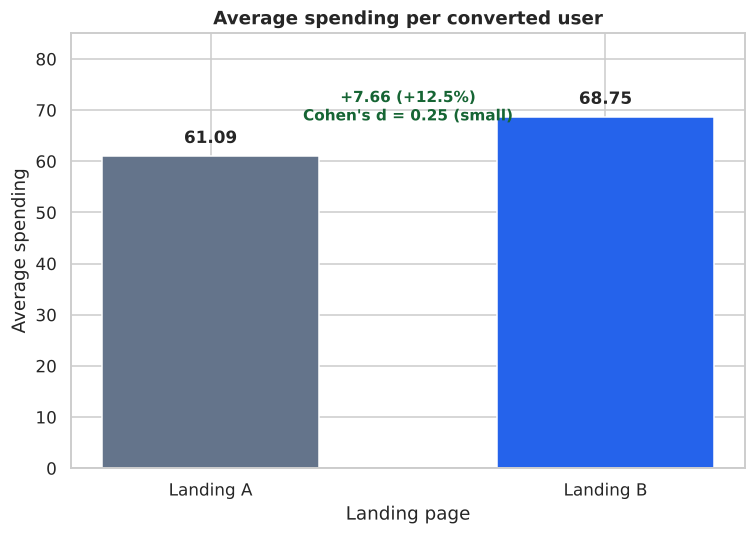

In [10]:
# Visualize the comparison of means
fig, ax = plt.subplots(figsize=(7, 5))
means = [spending_A.mean(), spending_B.mean()]
bars = ax.bar(["Landing A", "Landing B"], means, color=[PALETTE["A"], PALETTE["B"]], width=0.55)

ax.set_title("Average spending per converted user")
ax.set_xlabel("Landing page")
ax.set_ylabel("Average spending")
ax.set_ylim(0, 85)
for bar, value in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2.5, f"{value:.2f}",
            ha="center", fontweight="bold")
ax.annotate(f"+{difference:.2f} ({difference / spending_A.mean():+.1%})\nCohen's d = {cohens_d:.2f} (small)",
            xy=(0.5, 0.80), xycoords="axes fraction", ha="center",
            fontsize=10, color="#166534", fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# Summary table: users, conversions and average spending among converters
summary = (
    df.groupby("landing")
      .agg(users=("user_id", "nunique"),
           conversions=("converted", "sum"))
)

avg_spending_converted = (
    df.loc[df["converted"] == 1]
      .groupby("landing")["spending"]
      .mean()
      .rename("avg_spending_converted")
)

summary = summary.join(avg_spending_converted).reindex(["A", "B"])
summary["conversion_rate_%"] = (summary["conversions"] / summary["users"] * 100).round(2)
summary.round(2)

,users,conversions,avg_spending_converted,conversion_rate_%
landing,,,,
A,19982,2512,61.09,12.57
B,20018,3194,68.75,15.96


**Interpretation:** Landing page B produced more conversions than A (3,194 vs. 2,512) despite the two groups being nearly the same size, and its converters spent more on average. The Welch test supports the **spending** comparison only; the conversion-rate difference requires its own test, which is Section 3.

### 2.1 Sensitivity of the spending result to extreme values

Spending is right-skewed, so before the result is reported it has to be clear whether it rests on a small number of very large purchases. Two questions decide what to do with them:

1. **Are they errors or genuine purchases?** Errors are corrected or removed; genuine values are kept, because they are real revenue.
2. **Does the conclusion depend on them?** If the result holds with and without them, the question stops mattering.

In [12]:
# Outlier detection with the IQR rule, applied within each version separately
def iqr_bounds(series):
    """Return the Tukey fences for a series."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


outlier_summary = []
for version, series in [("A", spending_A), ("B", spending_B)]:
    low, high = iqr_bounds(series)
    outliers = series[(series < low) | (series > high)]
    outlier_summary.append({
        "version": version,
        "converted_users": len(series),
        "upper_fence": round(high, 2),
        "outliers": len(outliers),
        "outliers_%": round(len(outliers) / len(series) * 100, 2),
        "max": round(series.max(), 2),
        "revenue_share_%": round(outliers.sum() / series.sum() * 100, 1),
    })

outlier_table = pd.DataFrame(outlier_summary)
print(outlier_table.to_string(index=False))

# Are the extremes plausible values, or recording errors?
print("\nFive largest purchases, A:", sorted(spending_A.values)[-5:])
print("Five largest purchases, B:", sorted(spending_B.values)[-5:])
print(f"\nNegative spending values: {(df['spending'] < 0).sum()}")
print(f"Converted users with zero spending: {((df['converted'] == 1) & (df['spending'] == 0)).sum()}")

version  converted_users  upper_fence  outliers  outliers_%    max  revenue_share_%
      A             2512       126.17        71        2.83 303.68              7.3
      B             3194       142.88        89        2.79 249.99              6.8

Five largest purchases, A: [np.float64(207.15), np.float64(221.16), np.float64(225.93), np.float64(269.91), np.float64(303.68)]
Five largest purchases, B: [np.float64(224.01), np.float64(226.66), np.float64(231.37), np.float64(244.89), np.float64(249.99)]

Negative spending values: 0
Converted users with zero spending: 0


In [13]:
# Sensitivity check: does the Welch result survive without the extreme values?
low_A, high_A = iqr_bounds(spending_A)
low_B, high_B = iqr_bounds(spending_B)
trimmed_A = spending_A[(spending_A >= low_A) & (spending_A <= high_A)]
trimmed_B = spending_B[(spending_B >= low_B) & (spending_B <= high_B)]

t_trimmed = ttest_ind(trimmed_A, trimmed_B, equal_var=False)
pooled_sd_trimmed = np.sqrt((trimmed_A.var(ddof=1) + trimmed_B.var(ddof=1)) / 2)
d_trimmed = (trimmed_B.mean() - trimmed_A.mean()) / pooled_sd_trimmed

comparison = pd.DataFrame({
    "dataset": ["Full data", "Outliers removed (IQR)"],
    "mean_A": [spending_A.mean(), trimmed_A.mean()],
    "mean_B": [spending_B.mean(), trimmed_B.mean()],
    "difference": [spending_B.mean() - spending_A.mean(), trimmed_B.mean() - trimmed_A.mean()],
    "t": [t_stat, t_trimmed.statistic],
    "p_value": [p_value, t_trimmed.pvalue],
    "cohens_d": [cohens_d, d_trimmed],
}).round({"mean_A": 2, "mean_B": 2, "difference": 2, "t": 2, "cohens_d": 3})

print(comparison.to_string(index=False))

# Medians are unaffected by extreme values by construction
print(f"\nMedian spending A: {spending_A.median():.2f}")
print(f"Median spending B: {spending_B.median():.2f}")
print(f"Difference of medians (B - A): {spending_B.median() - spending_A.median():+.2f}")

               dataset  mean_A  mean_B  difference      t      p_value  cohens_d
             Full data   61.09   68.75        7.66  -9.48 3.627602e-21     0.251
Outliers removed (IQR)   58.27   65.88        7.61 -11.19 9.494331e-29     0.300

Median spending A: 55.84
Median spending B: 62.57
Difference of medians (B - A): +6.73


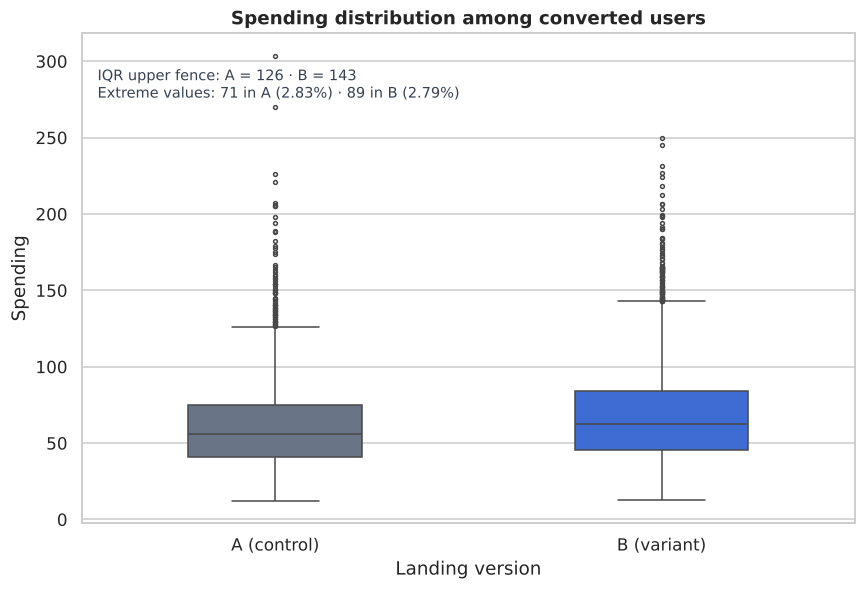

In [14]:
# Visualize the spread and the extremes that drive the question
spending_long = pd.DataFrame({
    "spending": pd.concat([spending_A, spending_B]),
    "version": ["A (control)"] * len(spending_A) + ["B (variant)"] * len(spending_B),
})

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=spending_long, x="version", y="spending", hue="version", legend=False,
            palette=[PALETTE["A"], PALETTE["B"]], width=0.45, fliersize=2.5, ax=ax)

ax.set_title("Spending distribution among converted users")
ax.set_xlabel("Landing version")
ax.set_ylabel("Spending")
ax.annotate(f"IQR upper fence: A = {high_A:.0f} · B = {high_B:.0f}\n"
            f"Extreme values: {outlier_table.loc[0, 'outliers']} in A ({outlier_table.loc[0, 'outliers_%']}%) · "
            f"{outlier_table.loc[1, 'outliers']} in B ({outlier_table.loc[1, 'outliers_%']}%)",
            xy=(0.02, 0.93), xycoords="axes fraction", fontsize=9.5, color="#374151",
            va="top")

plt.tight_layout()
plt.savefig(f"{ASSETS}/figure_1_spending_outliers.png")
plt.show()

### 📝 Conclusion and interpretation

**The extreme values are kept.** Three findings support that decision:

| | A | B |
|---|---|---|
| Converted users | 2,512 | 3,194 |
| Values beyond the IQR fence | 71 (**2.83%**) | 89 (**2.79%**) |
| Largest purchase | 303.68 | 249.99 |
| Share of the group's revenue | 7.3% | 6.8% |

1. **They are genuine purchases, not recording errors.** The largest values climb smoothly (207, 221, 226, 270, 304 in A) with no impossible figures, no negative amounts, and no converted user recorded with zero spending. A data-entry error looks like 30,368 or −50, not like 304 in a shop whose average purchase is 65.
2. **They are evenly distributed between versions** — 2.83% against 2.79%. Neither group is contaminated relative to the other, so removing them would correct no bias and would discard real revenue from both sides.
3. **The conclusion does not depend on them.** Re-running Welch's test without them gives a nearly identical difference (+7.61 vs +7.66) with a *smaller* p-value, and Cohen's d rises from 0.25 to 0.30 — the long tail adds variance to both groups rather than creating the effect. The difference of medians (+6.73), which extreme values cannot affect at all, points the same way.

**What this does leave open:** roughly 7% of revenue sits with 2.8% of buyers. If one version attracted disproportionately more large purchases, that would matter more than the difference in means — but it does not here, since the proportions are equal and A holds the single largest purchase. A dedicated analysis of the upper tail is listed in Section 8.

## 📈 Section 3 — Conversion rate (A vs B)

Assess whether there is a statistically significant difference in the **conversion rate** between landing pages A and B.

**Hypotheses**

- **H₀:** The conversion proportion is the same for landing pages A and B (p_A = p_B).
- **H₁:** The conversion proportions differ.

In [15]:
# Count conversions and total users for each landing page
conversions = df.groupby("landing")["converted"].sum()
total_users = df.groupby("landing")["user_id"].count()

counts = [conversions.loc["A"], conversions.loc["B"]]
nobs = [total_users.loc["A"], total_users.loc["B"]]

stat, pval = proportions_ztest(counts, nobs)
print(f"Z-test statistic: {stat:.4f}")
print(f"p-value: {pval:.3g}")
print(f"Significance level: {ALPHA}")

if pval < ALPHA:
    print("Reject the null hypothesis: there is a significant difference in conversion rates between the two landing pages.")
else:
    print("Fail to reject the null hypothesis: no significant difference in conversion rates between the two landing pages.")

rate_A = conversions.loc["A"] / total_users.loc["A"]
rate_B = conversions.loc["B"] / total_users.loc["B"]
print(f"\nConversion rate A: {rate_A:.2%}")
print(f"Conversion rate B: {rate_B:.2%}")
print(f"Absolute difference: {(rate_B - rate_A) * 100:+.2f} percentage points")
print(f"Relative difference: {(rate_B / rate_A - 1):+.2%}")

Z-test statistic: -9.6774
p-value: 3.76e-22
Significance level: 0.05
Reject the null hypothesis: there is a significant difference in conversion rates between the two landing pages.

Conversion rate A: 12.57%
Conversion rate B: 15.96%
Absolute difference: +3.38 percentage points
Relative difference: +26.92%


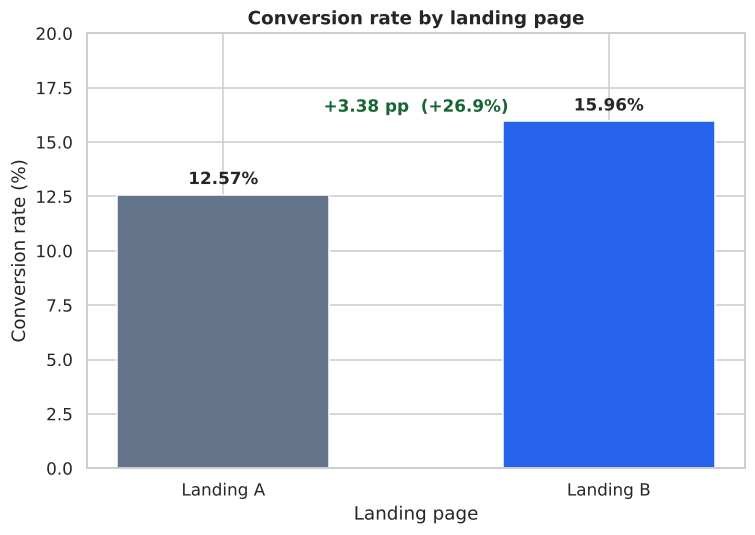

In [16]:
# Visualize the conversion rates
fig, ax = plt.subplots(figsize=(7, 5))
conversion_rates = df.groupby("landing")["converted"].mean() * 100
bars = ax.bar(["Landing A", "Landing B"], conversion_rates.values,
              color=[PALETTE["A"], PALETTE["B"]], width=0.55)

ax.set_title("Conversion rate by landing page")
ax.set_xlabel("Landing page")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, 20)
for bar, value in zip(bars, conversion_rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.5, f"{value:.2f}%",
            ha="center", fontweight="bold")
ax.annotate(f"+{(rate_B - rate_A) * 100:.2f} pp  ({(rate_B / rate_A - 1):+.1%})",
            xy=(0.5, 0.82), xycoords="axes fraction", ha="center",
            fontsize=11, color="#166534", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{ASSETS}/figure_2_conversion_rate_by_version.png")
plt.show()

### 📝 Conclusion and interpretation

**Decision:** reject H₀. The conversion rates of landing pages A and B are not equal (z = −9.68, p = 3.76 × 10⁻²²).

| Version | Users | Conversions | Conversion rate |
|---|---|---|---|
| A (control) | 19,982 | 2,512 | 12.57% |
| B (variant) | 20,018 | 3,194 | **15.96%** |

The difference is **+3.38 percentage points**, or **+26.9%** in relative terms — at the experiment's own volume, roughly 680 additional converted users per 20,000 visitors.

**Business interpretation:** this is strong evidence that the page version affects conversion performance, and it is the larger of the two effects measured. Where the spending difference is real but small (d = 0.25), the conversion difference is both significant and substantial, so it is the one that should carry the decision — subject to the guardrails listed in Section 7.

## 🔗 Section 4 — Conversion by traffic source

Analyze whether there is a statistically significant association between **traffic source** and **conversion**, to establish whether some channels convert better than others.

**Hypotheses**

- **H₀:** Traffic source and conversion are independent (the conversion rate is the same across traffic sources).
- **H₁:** Traffic source and conversion are not independent (at least one traffic source has a different conversion rate).

In [17]:
# Contingency table of COUNTS for the chi-square test.
# NOTE: the test must receive counts. The statistic scales with the table total, so a
# table normalized to percentages (total = 400 instead of 40,000) returns a meaninglessly
# small chi-square and a large p-value.
contingency_table = pd.crosstab(df["traffic_source"], df["converted"])

# Percentages are computed separately, for reading only.
proportions = pd.crosstab(df["traffic_source"], df["converted"], normalize="index") * 100

print("Counts used for the chi-square test:")
print(contingency_table.to_string())
print("\nConversion rate by traffic source (%):")
print(proportions.round(2).to_string())

Counts used for the chi-square test:
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Conversion rate by traffic source (%):
converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


In [18]:
# Apply the chi-square test
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected.round(1))

if p_val < ALPHA:
    print("\nReject the null hypothesis: there is a significant association between traffic source and conversion.")
else:
    print("\nFail to reject the null hypothesis: no significant association between traffic source and conversion.")


def check_expected_frequencies(expected):
    """Check if all expected frequencies are >= 5."""
    if (expected < 5).any():
        print("Warning: some expected frequencies are below 5. Consider Fisher's exact test or regrouping categories.")
    else:
        print("All expected frequencies are >= 5. The chi-square test is valid.")


check_expected_frequencies(expected)

# Effect size: a significant chi-square states that an association exists, not that it
# matters. Cramer's V places the association on a 0-1 scale that does not grow with n.
cramers_v = np.sqrt(chi2_stat / (len(df) * (min(contingency_table.shape) - 1)))
print(f"\nCramer's V: {cramers_v:.4f}   (0.1 = small | 0.3 = medium | 0.5 = large)")

Chi-square Statistic: 8.6621
p-value: 0.0341
Degrees of Freedom: 3
Expected Frequencies:
[[10232.5  1702.5]
 [ 5249.6   873.4]
 [15421.2  2565.8]
 [ 3390.8   564.2]]

Reject the null hypothesis: there is a significant association between traffic source and conversion.
All expected frequencies are >= 5. The chi-square test is valid.

Cramer's V: 0.0147   (0.1 = small | 0.3 = medium | 0.5 = large)


### 📝 Conclusion and interpretation

**Decision:** reject H₀. There **is** a statistically significant association between traffic source and conversion (**χ² = 8.66; p = 0.034**, dof = 3). All expected frequencies exceed 5, so the test is valid.

**But the effect is negligible:** **Cramér's V = 0.015**, far below the 0.10 threshold for a small effect. The conversion rates run from 13.79% (Organic) to 14.99% (Email) — the entire spread across the four channels is **1.2 percentage points**.

| Channel | Share of users | Conversion rate |
|---|---|---|
| Email | 15.3% | 14.99% |
| Ads | 29.8% | 14.74% |
| Referral | 9.9% | 13.88% |
| Organic | 45.0% | 13.79% |

> ⚠️ **Methodological note.** The chi-square test must be run on the contingency table of **counts**. Run on a table normalized to percentages, the same test returns χ² = 0.089, p = 0.993 — an apparently decisive "no association" that is purely an artifact of the table total being 400 instead of 40,000.

**Business interpretation:** with n = 40,000, a trivial difference clears any significance threshold. The effect size, not the p-value, is the decision-relevant quantity here, and 1.2 pp of spread is no basis for reallocating budget between channels. Conversion performance is, for practical purposes, similar across traffic sources.

## 👤 Section 5 — Conversion by user type

Analyze whether there is a statistically significant association between **user type** (new vs returning) and **conversion**.

**Hypotheses**

- **H₀:** `user_type` and `converted` are independent; the conversion rate is the same across user types.
- **H₁:** `user_type` and `converted` are not independent; at least one user type has a different conversion rate.

In [19]:
# Contingency table of counts, and percentages for reading
contingency_table_user_type = pd.crosstab(df["user_type"], df["converted"])
proportions_user_type = pd.crosstab(df["user_type"], df["converted"], normalize="index") * 100

print("Counts used for the chi-square test:")
print(contingency_table_user_type.to_string())
print("\nConversion rate by user type (%):")
print(proportions_user_type.round(2).to_string())

# Apply the chi-square test
chi2_user_type, p_user_type, dof_user_type, expected_user_type = chi2_contingency(contingency_table_user_type)
print(f"\nChi-square Statistic: {chi2_user_type:.4f}")
print(f"p-value: {p_user_type:.4f}")
print(f"Degrees of Freedom: {dof_user_type}")
print("Expected Frequencies:")
print(expected_user_type.round(1))

if p_user_type < ALPHA:
    print("\nReject the null hypothesis: there is a significant association between user type and conversion.")
else:
    print("\nFail to reject the null hypothesis: no significant association between user type and conversion.")

check_expected_frequencies(expected_user_type)

# Effect size, reported for the same reason as in Section 4
cramers_v_user_type = np.sqrt(chi2_user_type / (len(df) * (min(contingency_table_user_type.shape) - 1)))
print(f"\nCramer's V: {cramers_v_user_type:.4f}   (0.1 = small | 0.3 = medium | 0.5 = large)")

Counts used for the chi-square test:
converted      0     1
user_type             
New        22295  3738
Returning  11999  1968

Conversion rate by user type (%):
converted      0      1
user_type              
New        85.64  14.36
Returning  85.91  14.09

Chi-square Statistic: 0.5135
p-value: 0.4736
Degrees of Freedom: 1
Expected Frequencies:
[[22319.4  3713.6]
 [11974.6  1992.4]]

Fail to reject the null hypothesis: no significant association between user type and conversion.
All expected frequencies are >= 5. The chi-square test is valid.

Cramer's V: 0.0036   (0.1 = small | 0.3 = medium | 0.5 = large)


### 📝 Conclusion and interpretation

**Decision:** fail to reject H₀. The p-value of 0.474 is well above 0.05, so there is no statistically significant association between user type and conversion. **Cramér's V = 0.004** confirms it from the other direction: even if the test had reached significance, the association would be negligible.

New users convert at **14.36%** and returning users at **14.09%** — a gap of 0.27 percentage points, entirely compatible with random variation.

**Business interpretation:** conversion does not meaningfully differ by user type in this dataset, so there is no basis for treating new and returning visitors differently on the strength of this evidence.

## 📊 Section 6 — Visualization of the categorical results

Visually explore the relationship between the categorical variables (`traffic_source` and `user_type`) and conversion, showing for each category both the absolute number of users who converted and did not convert, and the proportion. This separates **volume** from **effectiveness**: a channel can carry many users and convert them at an ordinary rate.

### 6.1 Traffic source and conversion

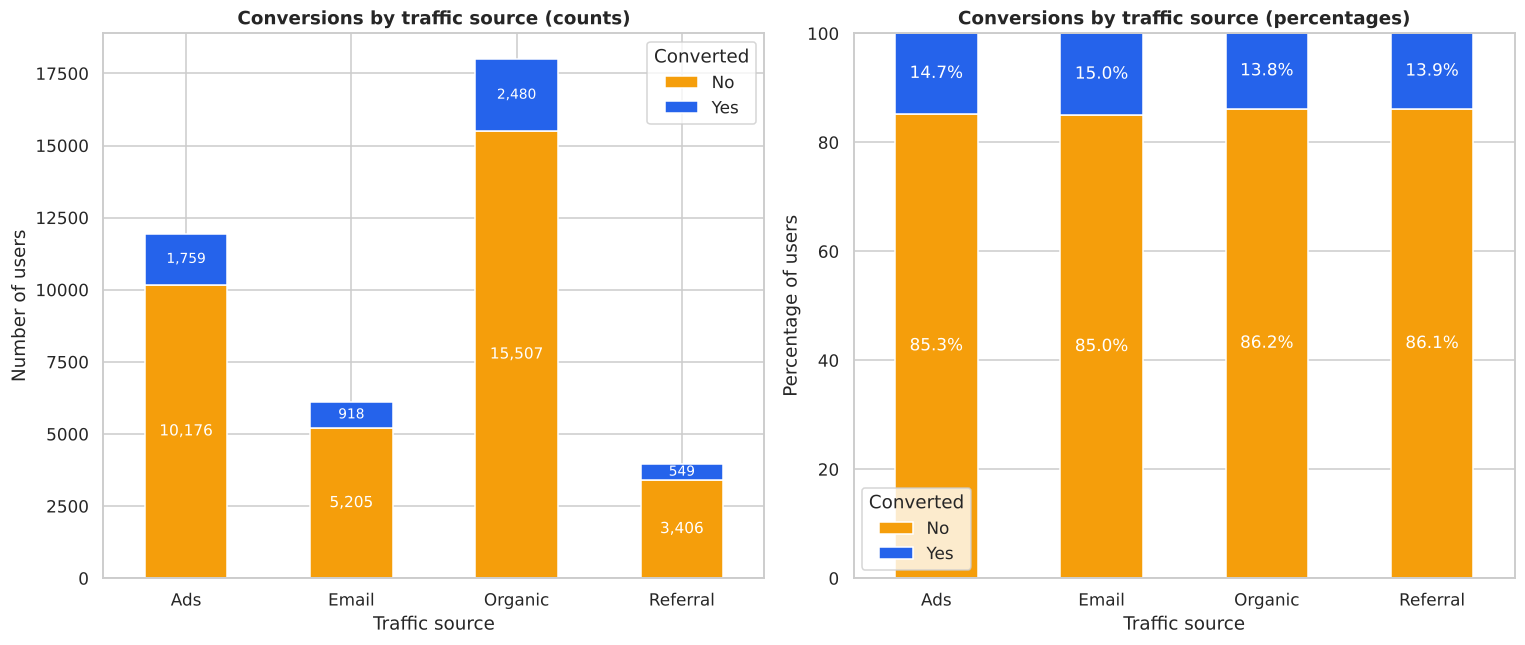

In [20]:
# Absolute counts and percentages by traffic source
traffic_counts = contingency_table.reindex(columns=[0, 1], fill_value=0)
traffic_percentages = traffic_counts.div(traffic_counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

traffic_counts.plot(kind="bar", stacked=True, ax=axes[0], color=["#F59E0B", "#2563EB"])
axes[0].set_title("Conversions by traffic source (counts)")
axes[0].set_xlabel("Traffic source")
axes[0].set_ylabel("Number of users")
axes[0].legend(title="Converted", labels=["No", "Yes"])
axes[0].tick_params(axis="x", rotation=0)

traffic_percentages.plot(kind="bar", stacked=True, ax=axes[1], color=["#F59E0B", "#2563EB"])
axes[1].set_title("Conversions by traffic source (percentages)")
axes[1].set_xlabel("Traffic source")
axes[1].set_ylabel("Percentage of users")
axes[1].set_ylim(0, 100)
axes[1].legend(title="Converted", labels=["No", "Yes"])
axes[1].tick_params(axis="x", rotation=0)

for i, (not_converted, converted) in enumerate(zip(traffic_counts[0], traffic_counts[1])):
    axes[0].text(i, not_converted / 2, f"{not_converted:,}", ha="center", va="center",
                 color="white", fontsize=10)
    axes[0].text(i, not_converted + converted / 2, f"{converted:,}", ha="center", va="center",
                 color="white", fontsize=9)

for i, (not_converted, converted) in enumerate(zip(traffic_percentages[0], traffic_percentages[1])):
    axes[1].text(i, not_converted / 2, f"{not_converted:.1f}%", ha="center", va="center", color="white")
    axes[1].text(i, not_converted + converted / 2, f"{converted:.1f}%", ha="center", va="center", color="white")

plt.tight_layout()
plt.savefig(f"{ASSETS}/figure_3_conversion_by_traffic_source.png")
plt.show()

✍️ **Interpretation:** the number of users per traffic source differs substantially in absolute terms — Organic alone carries 45% of the traffic — but the conversion rates are similar across all four channels. Volume and effectiveness are different things here, and the channel a user arrives through does not meaningfully change the likelihood that they convert.

### 6.2 User type and conversion

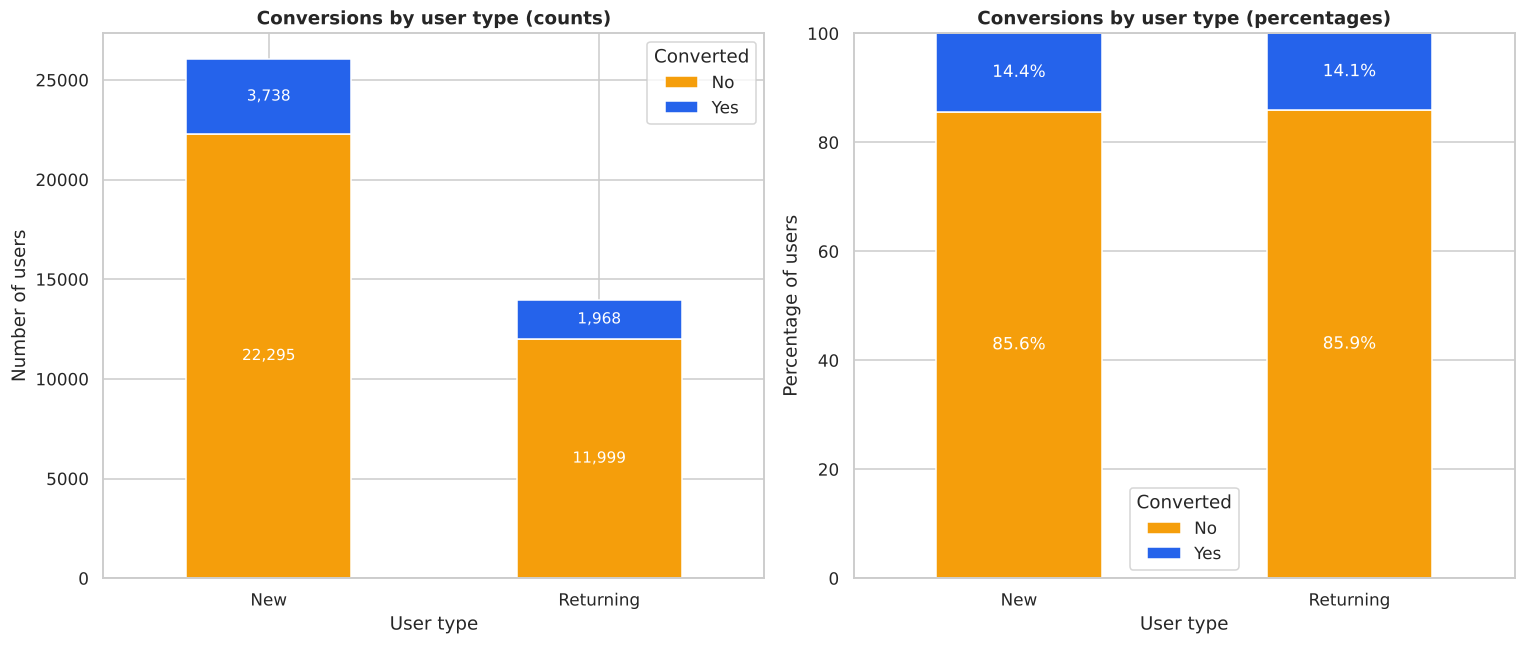

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

contingency_table_user_type.plot(kind="bar", stacked=True, ax=axes[0], color=["#F59E0B", "#2563EB"])
axes[0].set_title("Conversions by user type (counts)")
axes[0].set_xlabel("User type")
axes[0].set_ylabel("Number of users")
axes[0].legend(title="Converted", labels=["No", "Yes"])
axes[0].tick_params(axis="x", rotation=0)

proportions_user_type.plot(kind="bar", stacked=True, ax=axes[1], color=["#F59E0B", "#2563EB"])
axes[1].set_title("Conversions by user type (percentages)")
axes[1].set_xlabel("User type")
axes[1].set_ylabel("Percentage of users")
axes[1].set_ylim(0, 100)
axes[1].legend(title="Converted", labels=["No", "Yes"])
axes[1].tick_params(axis="x", rotation=0)

for i, (not_converted, converted) in enumerate(zip(contingency_table_user_type[0],
                                                  contingency_table_user_type[1])):
    axes[0].text(i, not_converted / 2, f"{not_converted:,}", ha="center", va="center",
                 color="white", fontsize=10)
    axes[0].text(i, not_converted + converted / 2, f"{converted:,}", ha="center", va="center",
                 color="white", fontsize=10)

for i, (not_converted, converted) in enumerate(zip(proportions_user_type[0], proportions_user_type[1])):
    axes[1].text(i, not_converted / 2, f"{not_converted:.1f}%", ha="center", va="center", color="white")
    axes[1].text(i, not_converted + converted / 2, f"{converted:.1f}%", ha="center", va="center", color="white")

plt.tight_layout()
plt.savefig(f"{ASSETS}/figure_4_conversion_by_user_type.png")
plt.show()

✍️ **Interpretation:** new users outnumber returning users roughly two to one, but the two groups convert at nearly the same rate. As with traffic source, the volume difference is real and the effectiveness difference is not.

## 🌟 Section 7 — Executive insight

*Written for stakeholders with no statistical background.*

The experiment included **40,000 users** over 28 days (2026-01-01 to 2026-01-28), split almost evenly between Landing Page A (**19,982**) and Landing Page B (**20,018**). No missing values, duplicate rows or repeated users were detected.

### Recommendation

**Implement Landing Page B.** It converts materially more visitors than A, and the visitors it converts spend somewhat more.

### Evidence

**Conversion rate**

- A converted **2,512 of 19,982** users — **12.57%**
- B converted **3,194 of 20,018** users — **15.96%**
- The difference is **+3.38 percentage points**, or **+26.9%** in relative terms, confirmed by a two-proportion z-test (**z = −9.68; p = 3.76 × 10⁻²²**)

At the experiment's own volume this is roughly **680 additional converted users per 20,000 visitors**. This is the larger of the two effects and the one that carries the recommendation.

**Average spending per converted user**

- A: **61.09** · B: **68.75** — a difference of **+7.66**, or **+12.5%**
- Welch's t-test confirms the difference (**t = −9.48; p = 3.63 × 10⁻²¹**), with a 95% confidence interval of **[+6.08, +9.24]**
- **Cohen's d = 0.25** — a *small* effect: the two spending distributions overlap substantially, so B raises the average purchase modestly rather than attracting a different kind of buyer

**Traffic source**

Conversion rates: Email **14.99%**, Ads **14.74%**, Referral **13.88%**, Organic **13.79%**.

The chi-square test on the table of counts found a statistically significant association (**χ² = 8.66; p = 0.034**), but the effect is negligible: **Cramér's V = 0.015**, with the entire spread across channels at **1.2 percentage points**. At n = 40,000 a trivial difference clears any significance threshold, so the effect size — not the p-value — is what the decision rests on. Budget should not be reallocated between channels on this evidence.

**User type**

New users converted at **14.36%**, returning users at **14.09%**. The 0.27 pp difference is not statistically significant (**χ² = 0.51; p = 0.474**) and negligible in size (**Cramér's V = 0.004**). User type does not meaningfully affect conversion in this dataset.

### Business recommendations

- **Prioritize implementing Landing Page B**, which significantly improves both the conversion rate and average spending among converted users.
- **Treat the conversion gain as the main prize.** At +26.9% relative, it is considerably more valuable than the +12.5% spending difference, whose effect size is small.
- **Do not segment the decision by channel or user type.** Neither variable shows a practically meaningful relationship with conversion.
- **Continue monitoring revenue per visitor, conversion quality and customer-acquisition cost** before making major budget changes by traffic source or user type.
- **Read every significant result alongside its effect size.** The traffic-source association is the clearest case in this analysis: statistically significant (p = 0.034) and practically irrelevant (V = 0.015, 1.2 pp of spread).

## 🔭 Section 8 — Recommended further analysis

The tests below were **not performed in this analysis**. They are the natural next steps before the roll-out decision is finalized, and each one closes a specific gap that the current evidence leaves open.

### Validate the experiment before acting on it

| Test | Question it answers | Why it matters here |
|---|---|---|
| **Sample ratio mismatch (SRM)** — χ² goodness of fit on the A/B split | Did the intended 50/50 allocation actually happen? | If assignment was not random, every comparison in this notebook is confounded. This belongs before the analysis, not after it |
| **Covariate balance tests** — χ² on region, device, traffic source and user type by version | Are the two groups comparable on characteristics the page did not cause? | Section 1 checks this descriptively only. A formal test rules out "B simply received better visitors" as an explanation for the lift |
| **Cross-exposure and data-rule checks** | Does any user appear in both versions? Does `gasto` > 0 hold only when `converted` = 1? | Repeated or cross-exposed users would break the independence assumption both tests rely on |

### Strengthen the comparisons already made

| Test | Question it answers | Why it matters here |
|---|---|---|
| **Shapiro-Wilk** on spending by group | Is the normality assumption behind the t-test defensible? | Complements Levene's test; spending is visibly right-skewed, and the assumption was not tested here |
| **Mann-Whitney U** on spending | Does the conclusion survive without any distributional assumption? | A rank-based test agreeing with Welch would confirm the skew did not drive the result |
| **Confidence interval for the difference in conversion proportions** | How large is the conversion lift, as a plausible range? | Section 3 reports a point estimate and a p-value; the spending comparison has an interval and the conversion comparison should too |

### Answer questions this analysis could not

| Test | Question it answers | Why it matters here |
|---|---|---|
| **Breslow-Day test of homogeneity of odds ratios** | Is B's advantage the same size in every channel and for both user types? | Sections 4 and 5 test whether segments differ in conversion, not whether the *version effect* differs by segment. This is the test that would justify a uniform roll-out rather than a segmented one |
| **Per-segment comparisons with Holm correction** | Which segments show a real lift once multiple testing is accounted for? | Running several segment tests inflates false positives; a correction is required before calling any of them a finding |
| **Bootstrap on revenue per exposed user** (total spending ÷ users exposed) | Which version is worth more per visitor, combining conversion and spending? | Conversion rate and average spending can disagree. A single combined metric settles the decision, and because ~86% of its values are zero, a resampling interval is more appropriate than a parametric one |

| **Upper-tail analysis of spending** | Does one version attract disproportionately more large purchases? | About 7% of revenue sits with the 2.8% of buyers beyond the IQR fence. Section 2.1 shows the two versions carry equal proportions of them, but the composition of that tail — and whether B's advantage holds inside it — was not examined |

### Beyond statistics

- **Post-launch holdout (5–10% on A for 4–8 weeks)** — distinguishes a durable improvement from a novelty effect, which a 28-day test cannot rule out.
- **Guardrail metrics** — refund and return rate, support contacts per order, and customer-acquisition cost by channel. This analysis measures revenue, not margin: more converters is only good news if they are not worse customers.
- **Element-level follow-up tests** — copy, layout, call-to-action, imagery. The experiment establishes *that* B works, never *why*.